In [ ]:
import numpy as np
import matplotlib
matplotlib.rcParams.update({'font.size': 16})
from trends_and_climatology_functions import get_monthly_observations, plot_monthly_boxplots,  plot_monthly_barplots, plot_double_hist_map, create_region_path, plot_hist_map, get_dict_list_for_labels, extract_result_dict, extract_n_obs_per_day_xarray, extract_result_dict_same_grid, extract_result_dict_xarray, calculate_daily_coverage_for_months, mk_test_for_months, theil_sen_multi_season, extract_merra_dict_list, load_dict_list, get_closest_indices
np.random.seed(42)
import os
import sys
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
plt.style.use('bmh')

import numpy as np
import matplotlib
from pyproj import Proj, transform
import xarray as xr
import cartopy.crs as ccrs
#import cKDTree


In [ ]:
bands=[31]
data_folder = "/" # Original data folder relative to this script
years = [yr for yr in range(2000, 2026)]
projection = ccrs.Stereographic(central_latitude=90)

#CAOnet
CAOnet_CAO_mask = xr.open_dataarray(data_folder + f"CAOnet_cao_mask_{years[0]}-{years[-1]}_final.nc")

x_grid = CAOnet_CAO_mask.lon.values
y_grid = CAOnet_CAO_mask.lat.values

In [4]:
# reshape the dataset to be 2x smaller in y and x dimensions
trim = 1
CAOnet_CAO_mask_coarse = CAOnet_CAO_mask.coarsen(dim={"y": trim, "x": trim}, boundary="trim").mean()
# take monthly means
# CAOnet_CAO_mask_coarse[1].plot()
isfinite = np.any(np.isfinite(CAOnet_CAO_mask_coarse), axis=0)
# CAOnet_CAO_mask_coarse = CAOnet_CAO_mask_coarse.where(isfinite, drop=True)
CAOnet_CAO_mask_coarse = CAOnet_CAO_mask_coarse.resample(time="1M").sum().where(isfinite, drop=True)


/uio/kant/geo-geofag-u1/fslippe/miniconda3/envs/shortening_CAO/lib/python3.13/site-packages/xarray/groupers.py:498: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


In [5]:
import importlib
import trends_and_climatology_functions
importlib.reload(trends_and_climatology_functions)
from trends_and_climatology_functions import mk_test_for_months

months = [9, 10, 11, 12, 1, 2, 3, 4, 5]
models = {
    "CAOnet": CAOnet_CAO_mask,
}



array_lists = {}
arrs = {}
slopes = {}
intercepts = {}
p_values = {}
slopes_5 = {}
slopes_95 = {}
valid_indices = np.where(np.any(np.isfinite(CAOnet_CAO_mask_coarse), axis=0))


for model_name, mask in models.items():
    su = 0
    array_lists[model_name] = []#np.full(CAOnet_CAO_mask_coarse.shape, np.nan)
    arrs[model_name] = []#np.full(CAOnet_CAO_mask_coarse.shape, np.nan)
    slopes[model_name] = []#np.full(CAOnet_CAO_mask_coarse.shape, np.nan)
    intercepts[model_name] = []#np.full(CAOnet_CAO_mask_coarse.shape, np.nan)
    p_values[model_name] = []#np.full(CAOnet_CAO_mask_coarse.shape, np.nan)
    slopes_5[model_name] = []#np.full(CAOnet_CAO_mask_coarse.shape, np.nan)
    slopes_95[model_name] = []#np.full(CAOnet_CAO_mask_coarse.shape, np.nan)
    for i in range(CAOnet_CAO_mask_coarse.shape[1]):
        for j in range(CAOnet_CAO_mask_coarse.shape[2]):
            if (i, j) in zip(*valid_indices):
                print(su, end="\r")
                su+=1
                array_list = [CAOnet_CAO_mask_coarse.where(CAOnet_CAO_mask_coarse["time.month"]==m, drop=True).values[:, i, j] for m in months]

                # array_list = [CAOnet_CAO_mask_coarse.where(CAOnet_CAO_mask_coarse["time.month"]==m, drop=True).values[:, i, j] for m in months]
                array_lists[model_name].append(array_list)
                    # print(array_lists[model_name].shape)
                # arrs[model_name][:, i, j] = arr
                s, ic, p, s5, s95 = mk_test_for_months(array_list, months)
                slopes[model_name].append(s)
                intercepts[model_name].append(ic)
                p_values[model_name].append(p)
                slopes_5[model_name].append(s5)
                slopes_95[model_name].append(s95)




/uio/kant/geo-geofag-u1/fslippe/miniconda3/envs/shortening_CAO/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


/uio/kant/geo-geofag-u1/fslippe/miniconda3/envs/shortening_CAO/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


/uio/kant/geo-geofag-u1/fslippe/miniconda3/envs/shortening_CAO/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


/uio/kant/geo-geofag-u1/fslippe/miniconda3/envs/shortening_CAO/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


/uio/kant/geo-geofag-u1/fslippe/miniconda3/envs/shortening_CAO/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/uio/kant/geo-geofag-u1/fslippe/miniconda3/envs/shortening_CAO/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/uio/kant/geo-geofag-u1/fslippe/miniconda3/envs/shortening_CAO/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/uio/kant/geo-geofag-u1/fslippe/miniconda3/envs/shortening_CAO/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


...

/uio/kant/geo-geofag-u1/fslippe/miniconda3/envs/shortening_CAO/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


/uio/kant/geo-geofag-u1/fslippe/miniconda3/envs/shortening_CAO/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


/uio/kant/geo-geofag-u1/fslippe/miniconda3/envs/shortening_CAO/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


/uio/kant/geo-geofag-u1/fslippe/miniconda3/envs/shortening_CAO/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


/uio/kant/geo-geofag-u1/fslippe/miniconda3/envs/shortening_CAO/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


In [ ]:

monthly_slopes = []
monthly_p_values = []
for m_i, month in enumerate(months):
    slope_map_i = np.full(CAOnet_CAO_mask_coarse.shape[1:3], np.nan)
    p_map_i = np.full(CAOnet_CAO_mask_coarse.shape[1:3], np.nan)
    for idx, (i, j) in enumerate(zip(*valid_indices)):
        slope_map_i[i, j] = np.array(slopes["CAOnet"])[idx, m_i]*25
        p_map_i[i, j] = np.array(p_values["CAOnet"])[idx, m_i]

    monthly_slopes.append(xr.DataArray(slope_map_i, dims=['y', 'x']))
    monthly_p_values.append(xr.DataArray(p_map_i, dims=['y', 'x']))

slopes_ds = xr.Dataset(data_vars=dict(slope=(["month", "y", "x"], monthly_slopes)),
                       coords=dict(
        lon=(("y", "x"), CAOnet_CAO_mask_coarse.lon.values), lat=(("y", "x"), CAOnet_CAO_mask_coarse.lat.values), month=("month", months))
    ).slope
p_values_ds = xr.Dataset(data_vars=dict(p_values=(["month", "y", "x"], monthly_p_values)),
                         coords=dict(
        lon=(("y", "x"), CAOnet_CAO_mask_coarse.lon.values), lat=(("y", "x"), CAOnet_CAO_mask_coarse.lat.values), month=("month", months)
    )).p_values

0.002838809542227846
0.058455205288234544
0.0009829823600505953
-1
-1
-1
-1
-1
0.16991295403230983


/uio/kant/geo-geofag-u1/fslippe/Shortening_Arctic_CAO_season/code/interactive_notebook/trends_and_climatology_functions.py:486: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0.05, 1, 1))


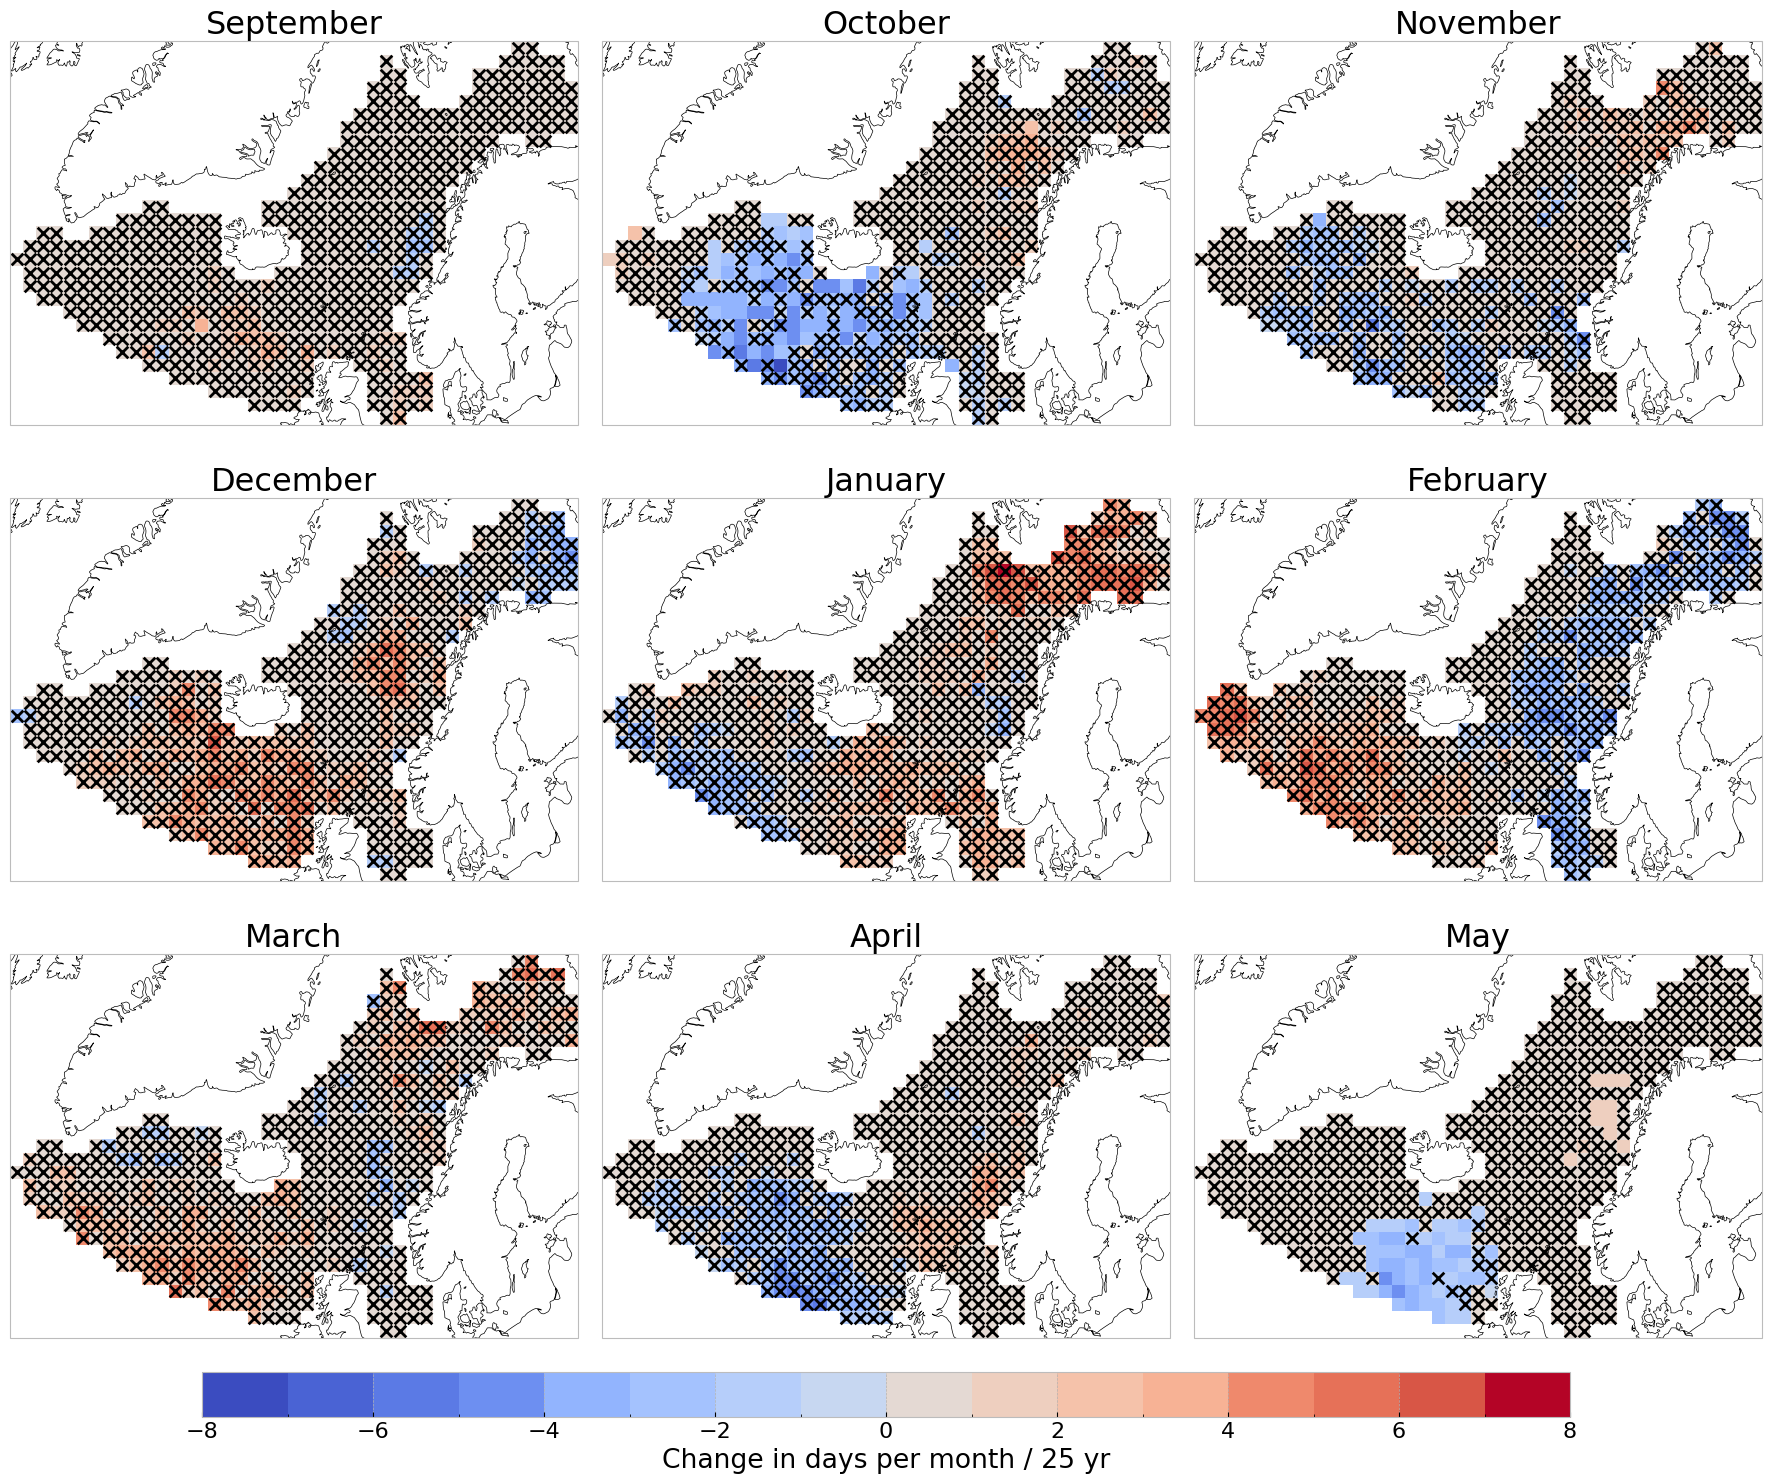

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import trends_and_climatology_functions
importlib.reload(trends_and_climatology_functions)

from trends_and_climatology_functions import plot_monthly_slopes

lon_condition = (CAOnet_CAO_mask_coarse['lon'] >= -45) & (CAOnet_CAO_mask_coarse['lon'] < 60)
lat_condition = (CAOnet_CAO_mask_coarse['lat'] >= 55) & (CAOnet_CAO_mask_coarse['lat'] < 82)
exclude_area = ~((CAOnet_CAO_mask_coarse['lon'] > 15) & (CAOnet_CAO_mask_coarse['lat'] < 65))
region_mask = lon_condition & lat_condition & exclude_area

plot_monthly_slopes(slopes_ds, region_mask, p_values_ds, FDR=0.2, vval=8)


In [35]:
ds_regrid = xr.open_dataset("../../data/MERRA2_CLDTOT_CAOgrid.2000-2025.nc")
ds_CAO = ds_regrid.where(CAOnet_CAO_mask==1)#.isel(time=0).CLDTOT.plot()
ds_noCAO = ds_regrid.where(CAOnet_CAO_mask==0)#.isel(time=0).CLDTOT.plot()

In [36]:
obs_mask = (~CAOnet_CAO_mask.isnull()).mean(axis=0)*100#.plot(vmax=1)

x_grid_obs = np.where(obs_mask.values>=90, x_grid, np.nan)
y_grid_obs = np.where(obs_mask.values>=90, y_grid, np.nan)

x_grid_obs_wo = np.where(obs_mask.values>0, x_grid, np.nan)
y_grid_obs_wo = np.where(obs_mask.values>0, y_grid, np.nan)

sw = (x_grid_obs_wo>=-45) & (x_grid_obs_wo<-20) & (y_grid_obs_wo < 70) & (y_grid_obs_wo > 55)
region_sw = np.where(sw & np.isfinite(x_grid_obs))

se = (x_grid_obs_wo>=-20) & (y_grid_obs_wo < 65)  & (y_grid_obs_wo > 55)  & ~((x_grid_obs_wo>15) & (y_grid_obs_wo < 65))
region_se = np.where(se  & np.isfinite(x_grid_obs))

mid = ((x_grid_obs_wo >= -25) & (x_grid_obs_wo < -25) & (y_grid_obs_wo > 70) & (y_grid_obs_wo < 82)) |  ((x_grid_obs_wo >= -25) & (x_grid_obs_wo<25) & (y_grid_obs_wo >= 65) & (y_grid_obs_wo < 82)) & ~((y_grid_obs_wo <68) & (x_grid_obs_wo >20))
region_mid = np.where(mid  & np.isfinite(x_grid_obs))

bar = (x_grid_obs_wo>=25) & (y_grid_obs_wo >= 68) & (y_grid_obs_wo < 82) & (x_grid_obs_wo < 60)
region_bar = np.where(bar  & np.isfinite(x_grid_obs))

south = (x_grid_obs_wo>=-45) & (x_grid_obs_wo<-20) & (y_grid_obs_wo < 65) & (y_grid_obs_wo > 55) | se
region_south = np.where(south  & np.isfinite(x_grid_obs))

all_ = sw | se | mid | bar 
north = mid | bar 
region_north = np.where(north & np.isfinite(x_grid_obs))
region_all = np.where(all_ & np.isfinite(x_grid_obs))
region_all_wo_thr = np.where(all_ & np.isfinite(x_grid_obs_wo))

In [37]:
ds_CAO_mean = ds_CAO.mean(dim=["x", "y"])
ds_noCAO_mean = ds_noCAO.mean(dim=["x", "y"])

CAO_fraction = CAOnet_CAO_mask.where(CAOnet_CAO_mask==1).sum(dim=("x", "y")) / np.sum(all_)
CAO_cloud_contribution = ds_CAO_mean * CAO_fraction * 100
noCAO_cloud_contribution = ds_noCAO_mean * (1-CAO_fraction) * 100

contribution_fraction = CAO_cloud_contribution / (CAO_cloud_contribution + noCAO_cloud_contribution)
contribution_monthly = contribution_fraction.groupby("time.month").mean()*100

<BarContainer object of 9 artists>

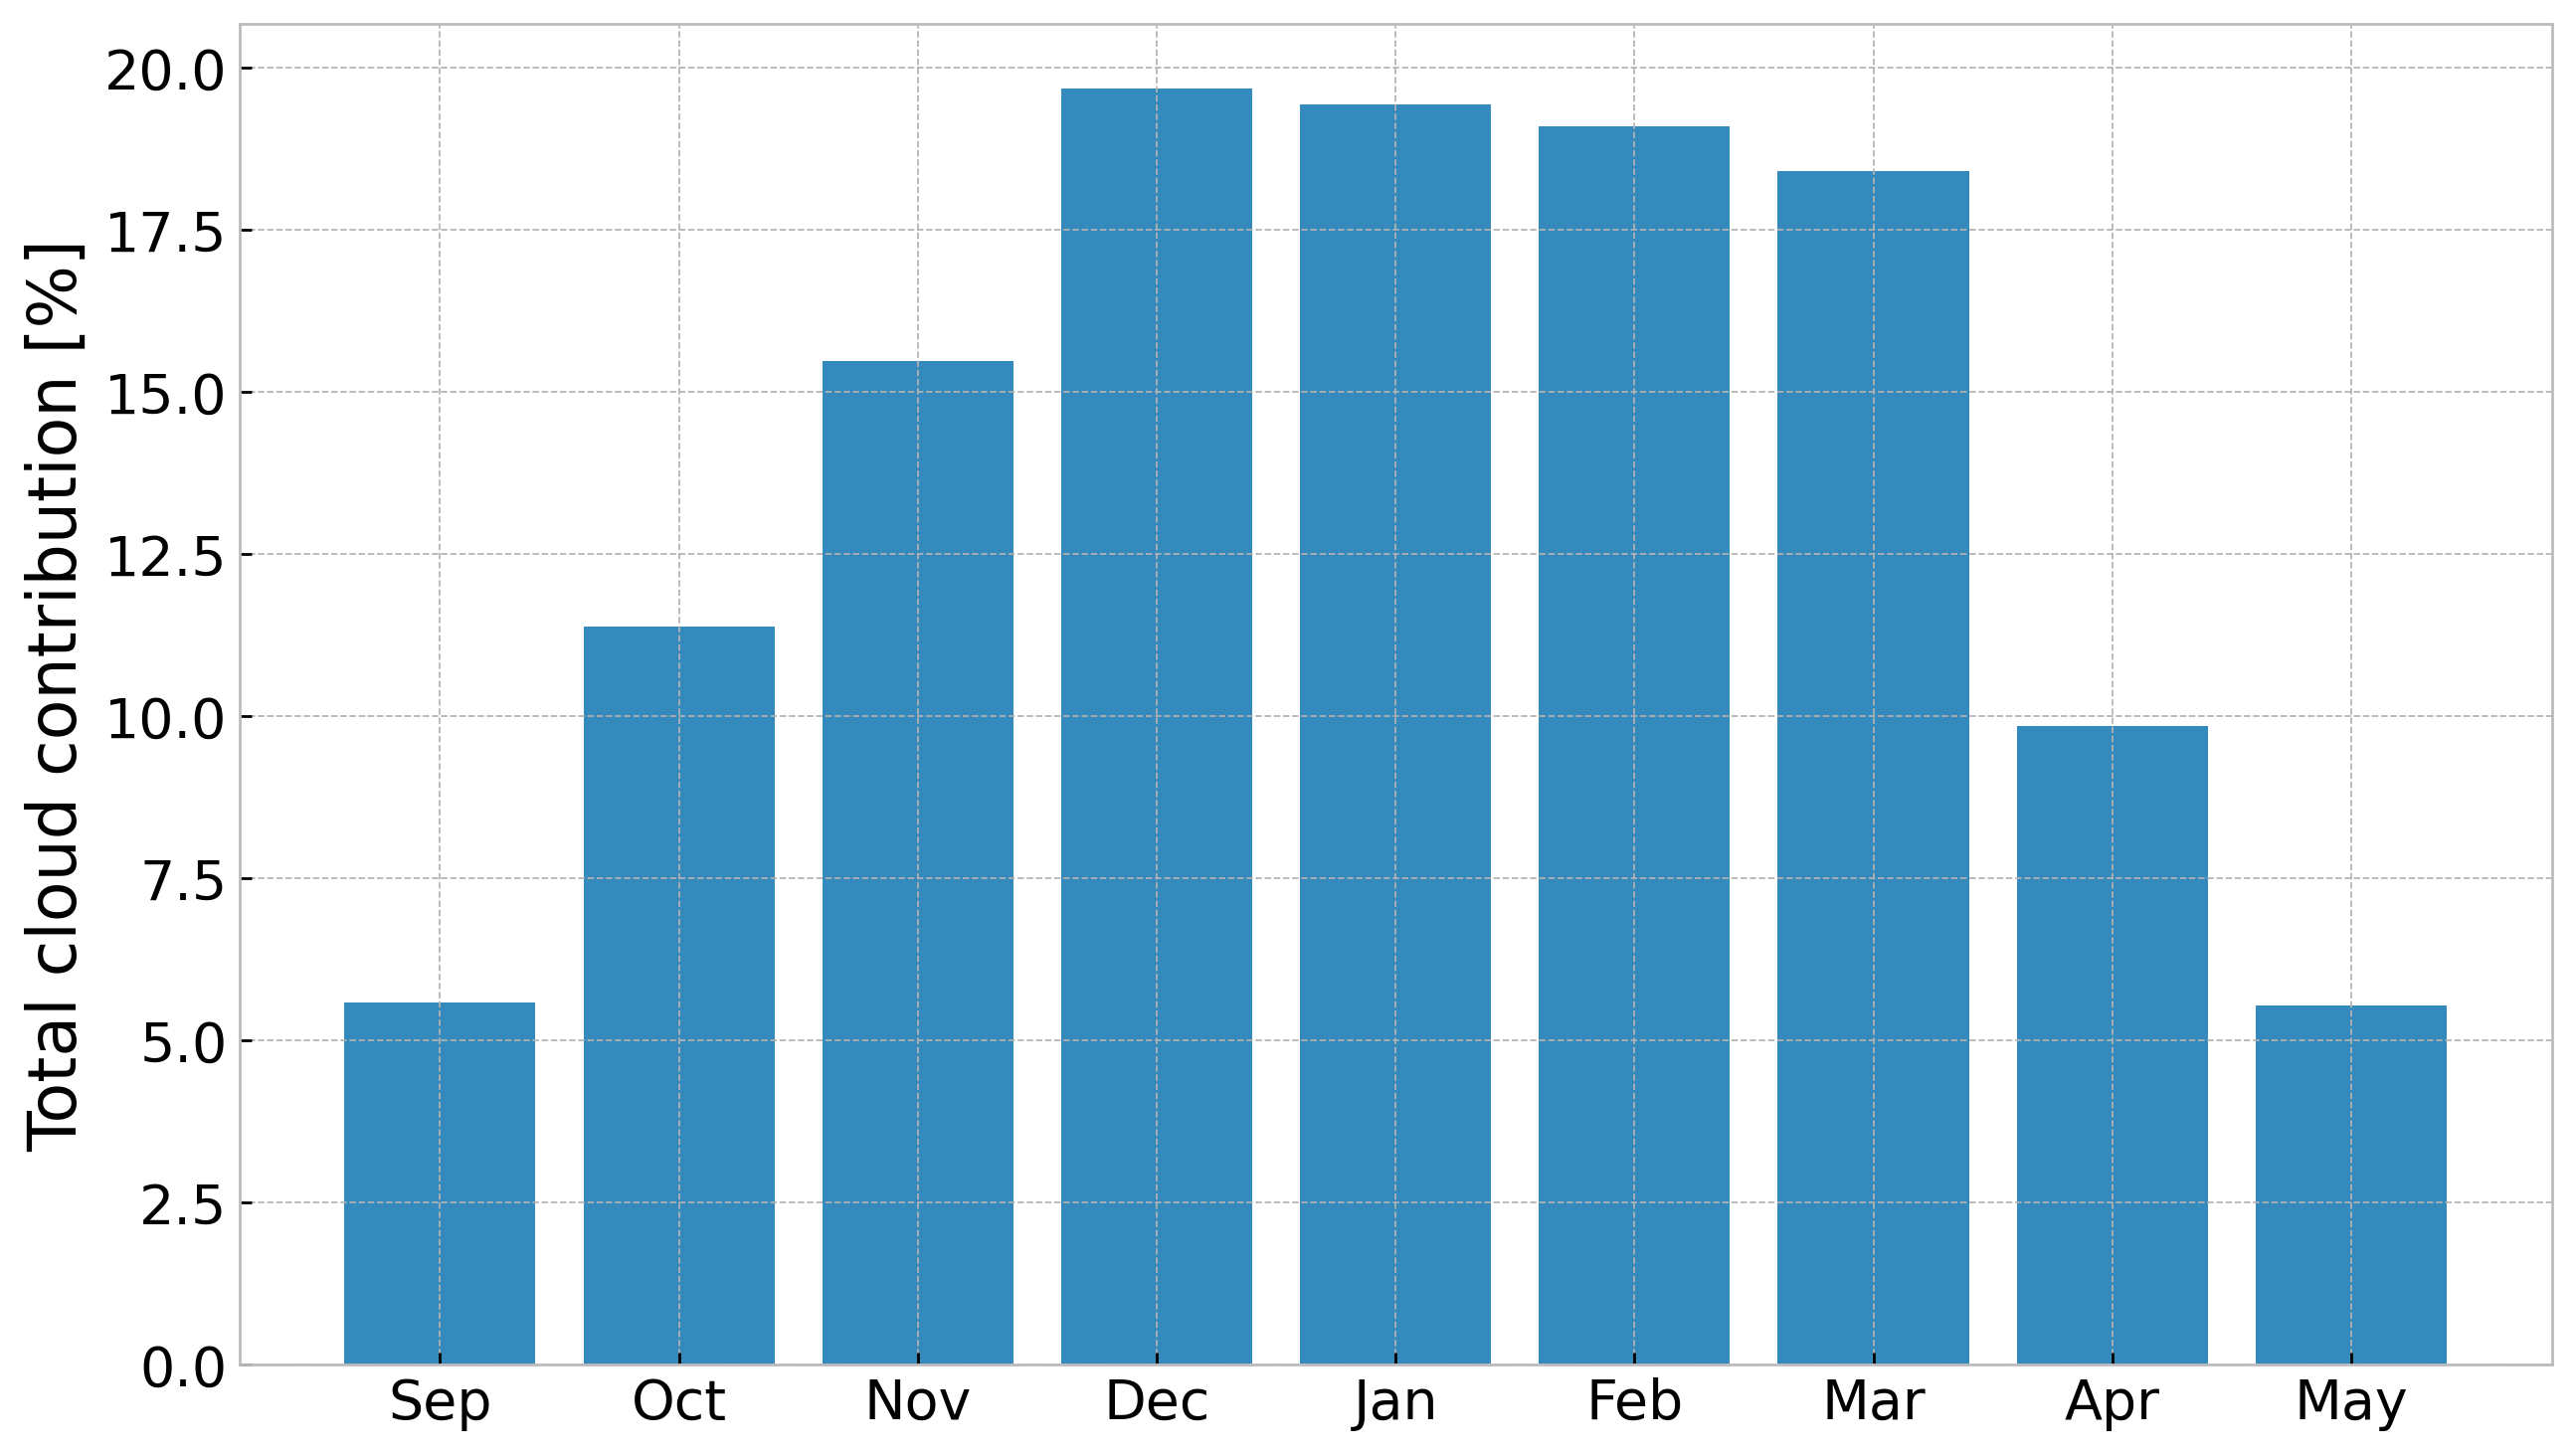

In [45]:
fig, axs = plt.subplots(1,1, dpi=250, figsize=(12, 7))
labels = ["Total cloud", "Low cloud", "Mid cloud", "High cloud"]
mean_coverage = (CAOnet_CAO_mask.where(CAOnet_CAO_mask==1).sum(dim=("x", "y"))/np.sum(all_)).groupby("time.month").mean()

# for i, var in enumerate(["CLDTOT", "CLDLOW", "CLDMID", "CLDHGH"]):
import calendar
#     import calendar
#     months_sorted = np.sort(months)
#     month_str_sorted = [calendar.month_name[m][:3] for m in months_sorted]
#     axs.plot(months_str, [contribution_monthly.sel(month=m)[var] for m in months],  marker="o", linestyle="-", label=labels[i])
axs.set_ylabel(f"Total cloud contribution [%]")
axs.set_facecolor('white')
months = [9, 10, 11, 12, 1, 2, 3, 4, 5]

months_str = [calendar.month_name[m][:3] for m in months]
# axs.set_title(f"CAO presence for different cloud types")
axs.bar(months_str, [contribution_monthly["CLDTOT"].sel(month=m).values for m in months], label="Total cloud contribution")
# axs.legend(loc="upper left")
